In [ ]:
import pandas as pd
import polars as pl
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import pandas as pd

dados=pd.read_parquet('tracks_features.csv_POLARS.parquet')
dados=dados.dropna() #Para excluir valores nulos
display(dados.describe())

In [ ]:
import polars as pl

arquivo=pl.read_csv("tracks_features.csv_POLARS.parquet") #caminhos dos arquivos

display(arquivo.head())

Conversão de CSV em PARQUET

In [7]:
arquivo_csv = 'tracks_features.csv'
arquivo_parquet = 'tracks_features.csv_POLARS.parquet'

# 1. scan_csv() apenas cria o plano (LazyFrame)
lazy_query = pl.scan_csv(arquivo_csv, separator=',', encoding='utf8-lossy')

# 2. sink_parquet() executa o plano em modo streaming
#    e salva o resultado direto no disco.
lazy_query.sink_parquet(arquivo_parquet)

print(f"Arquivo '{arquivo_csv}' convertido para '{arquivo_parquet}' com sucesso!")

Arquivo 'tracks_features.csv' convertido para 'tracks_features.csv_POLARS.parquet' com sucesso!


In [1]:
import polars as pl
import time

# 1. Modo Lazy: Estamos apenas escaneando o arquivo, sem carregar para a RAM
# scan_parquet já inicia em modo lazy por padrão.
q = (
    pl.scan_parquet("tracks_features.csv_POLARS.parquet")
    .filter(pl.col("explicit") == True)
)

print(type(q)) # Note que é um LazyFrame, não um DataFrame
print("\n")

# 2. O Plano de Execução (Explain)
print("--- Plano de Execução (Explain) ---")
print("O Polars analisou sua query e otimizou o caminho antes de tocar nos dados:")
print(q.explain())
print("\n")

# 3. Execução Real (Collect)
print("--- Executando (Collect) ---")
start_time = time.time()
df_resultado = q.collect()
end_time = time.time()

display(df_resultado)

<class 'polars.lazyframe.frame.LazyFrame'>


--- Plano de Execução (Explain) ---
O Polars analisou sua query e otimizou o caminho antes de tocar nos dados:
Parquet SCAN [tracks_features.csv_POLARS.parquet]
PROJECT */24 COLUMNS
SELECTION: [(col("explicit")) == (true)]
ESTIMATED ROWS: 1204025


--- Executando (Collect) ---


id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
str,str,str,str,str,str,i64,i64,bool,f64,f64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64,f64,i64,str
"""1wsRitfRRtWyEapl0q22o8""","""Guerrilla Radio""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",2,1,true,0.599,0.957,11,-5.764,1,0.188,0.0129,0.0000706,0.155,0.489,103.68,206200,4.0,1999,"""1999-11-02"""
"""2lbASgTSoDO7MTuLAXlTW0""","""Mic Check""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",4,1,true,0.44,0.967,11,-5.83,0,0.237,0.163,0.000004,0.121,0.574,96.752,213640,4.0,1999,"""1999-11-02"""
"""7o2Razxnl33Jrgz4PpMYNa""","""Ashes In the Fall""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",11,1,true,0.456,0.704,7,-6.687,1,0.0982,0.0052,0.000004,0.0595,0.656,140.629,277267,4.0,1999,"""1999-11-02"""
"""6ZU9RJIZ0fNaFuQM57bDIA""","""Bombtrack""","""Rage Against The Machine""","""4LaRYkT4oy47wEuQgkLBul""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",1,1,true,0.478,0.855,4,-7.438,0,0.121,0.0134,0.0000318,0.179,0.668,151.93,243760,4.0,1992,"""1992-11-03"""
"""3FUS56gKr9mVBmzvlnodlh""","""Killing In the Name""","""Rage Against The Machine""","""4LaRYkT4oy47wEuQgkLBul""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",2,1,true,0.457,0.779,7,-6.323,1,0.257,0.0185,0.000002,0.0247,0.734,86.573,313667,4.0,1992,"""1992-11-03"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""26w9NTiE9NGjW1ZvIOd1So""","""BOOKER T""","""EL ÚLTIMO TOUR DEL MUNDO""","""2d9BCZeAAhiZWPpbX9aPCW""","""['Bad Bunny']""","""['4q3ewBCX7sLwd24euuV69X']""",9,1,true,0.883,0.6,7,-7.188,1,0.37,0.114,0.000008,0.0931,0.691,113.903,156430,4.0,2020,"""2020-11-27"""
"""67ACYA3UI6QMNtHX6b34wX""","""LA DROGA""","""EL ÚLTIMO TOUR DEL MUNDO""","""2d9BCZeAAhiZWPpbX9aPCW""","""['Bad Bunny']""","""['4q3ewBCX7sLwd24euuV69X']""",10,1,true,0.643,0.727,1,-5.506,1,0.0389,0.0439,0.0,0.123,0.295,90.019,162299,4.0,2020,"""2020-11-27"""
"""4MzXwWMhyBbmu6hOcLVD49""","""DÁKITI""","""EL ÚLTIMO TOUR DEL MUNDO""","""2d9BCZeAAhiZWPpbX9aPCW""","""['Bad Bunny', 'Jhay Cortez']""","""['4q3ewBCX7sLwd24euuV69X', '0E…",11,1,true,0.731,0.573,4,-10.059,0,0.0544,0.401,0.0000522,0.113,0.145,109.928,205090,4.0,2020,"""2020-11-27"""


In [9]:
analise_danceability = (
    pl.scan_parquet("tracks_features.csv_POLARS.parquet")        

    .group_by("danceability")
    .agg([
        pl.col("duration_ms").mean().alias("valor_medio"),
        pl.col("duration_ms").count().alias("total_duracao")
    ])
    .sort("valor_medio", descending=True)
)

display(analise_danceability.collect())

danceability,valor_medio,total_duracao
f64,f64,u32
0.0529,3.263e6,1
0.0556,838677.0,3
0.0551,837699.4,5
0.0575,730016.166667,6
0.073,693734.947368,19
…,…,…
0.0507,77427.0,1
0.0516,76227.0,1
0.0484,56000.0,1


### Manipulação do Parquet e StringCache

In [2]:
inicial = (
    pl.scan_parquet("tracks_features.csv_POLARS.parquet")
)

display(inicial.collect())

id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
str,str,str,str,str,str,i64,i64,bool,f64,f64,i64,f64,i64,f64,f64,f64,f64,f64,f64,i64,f64,i64,str
"""7lmeHLHBe4nmXzuXc0HDjk""","""Testify""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",1,1,false,0.47,0.978,7,-5.399,1,0.0727,0.0261,0.0000109,0.356,0.503,117.906,210133,4.0,1999,"""1999-11-02"""
"""1wsRitfRRtWyEapl0q22o8""","""Guerrilla Radio""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",2,1,true,0.599,0.957,11,-5.764,1,0.188,0.0129,0.0000706,0.155,0.489,103.68,206200,4.0,1999,"""1999-11-02"""
"""1hR0fIFK2qRG3f3RF70pb7""","""Calm Like a Bomb""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",3,1,false,0.315,0.97,7,-5.424,1,0.483,0.0234,0.000002,0.122,0.37,149.749,298893,4.0,1999,"""1999-11-02"""
"""2lbASgTSoDO7MTuLAXlTW0""","""Mic Check""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",4,1,true,0.44,0.967,11,-5.83,0,0.237,0.163,0.000004,0.121,0.574,96.752,213640,4.0,1999,"""1999-11-02"""
"""1MQTmpYOZ6fcMQc56Hdo7T""","""Sleep Now In the Fire""","""The Battle Of Los Angeles""","""2eia0myWFgoHuttJytCxgX""","""['Rage Against The Machine']""","""['2d0hyoQ5ynDBnkvAbJKORj']""",5,1,false,0.426,0.929,2,-6.729,1,0.0701,0.00162,0.105,0.0789,0.539,127.059,205600,4.0,1999,"""1999-11-02"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""0EsMifwUmMfJZxzoMPXJKZ""","""Gospel of Juke""","""Notch - EP""","""38O5Ys0W9PFS5K7dMb7yKb""","""['FVLCRVM']""","""['7AjItKsRnEYRSiBt2OxK1y']""",2,1,false,0.264,0.966,5,-6.97,0,0.0672,0.00935,0.00224,0.337,0.415,159.586,276213,4.0,2014,"""2014-01-09"""
"""2WSc2TB1CSJgGE0PEzVeiu""","""Prism Visions""","""Notch - EP""","""38O5Ys0W9PFS5K7dMb7yKb""","""['FVLCRVM']""","""['7AjItKsRnEYRSiBt2OxK1y']""",3,1,false,0.796,0.701,11,-6.602,0,0.0883,0.104,0.644,0.0749,0.781,121.98,363179,4.0,2014,"""2014-01-09"""
"""6iProIgUe3ETpO6UT0v5Hg""","""Tokyo 360""","""Notch - EP""","""38O5Ys0W9PFS5K7dMb7yKb""","""['FVLCRVM']""","""['7AjItKsRnEYRSiBt2OxK1y']""",4,1,false,0.785,0.796,9,-5.96,0,0.0564,0.0304,0.918,0.0664,0.467,121.996,385335,4.0,2014,"""2014-01-09"""


### Métricas: Média, Mediana, Moda, Variância, Desvio Padrão, Amplitude

In [3]:
# Construindo a expressão de cálculo
metricas1 = inicial.select([
    pl.col("danceability").mean().alias("Média"),
    pl.col("danceability").median().alias("Mediana"),
    # Moda retorna uma lista, pegamos o primeiro valor
    pl.col("danceability").mode().first().alias("Moda"),
    pl.col("danceability").var().alias("Variância"),
    pl.col("danceability").std().alias("Desvio_Padrão"),
    (pl.col("danceability").max() - pl.col("danceability").min()).alias("Amplitude_Total")
]).collect()

print("\n--- Estatísticas Descritivas (Valor do Benefício) ---")
display(metricas1)


--- Estatísticas Descritivas (Valor do Benefício) ---


Média,Mediana,Moda,Variância,Desvio_Padrão,Amplitude_Total
f64,f64,f64,f64,f64,f64
0.493057,0.501,0.0,0.035974,0.189669,1.0


In [10]:
metricas2 = inicial.select([
    pl.col("danceability").quantile(0.25).alias("Q1"),
    pl.col("danceability").quantile(0.50).alias("Q2"),
    pl.col("danceability").quantile(0.75).alias("Q3"),
    pl.col("danceability").skew().alias("Assimetria"),
    pl.col("danceability").kurtosis().alias("Curtose")
]).collect()

print("\n--- Quartis e Forma da Distribuição ---")
display(metricas2)

# Análise rápida da Assimetria
assimetria = metricas2["Assimetria"][0]
print(f"\nInterpretação da Assimetria ({assimetria:.2f}):")
if -0.5 <= assimetria <= 0.5:
    print("-> Distribuição Simétrica (Dados bem balanceados)")
elif assimetria > 0.5:
    print("-> Assimétrica Positiva (Cauda para a direita - Existem valores muito altos puxando a média)")
else:
    print("-> Assimétrica Negativa (Cauda para a esquerda)")


--- Quartis e Forma da Distribuição ---


Q1,Q2,Q3,Assimetria,Curtose
f64,f64,f64,f64,f64
0.356,0.501,0.633,-0.101539,-0.608495



Interpretação da Assimetria (-0.10):
-> Distribuição Simétrica (Dados bem balanceados)


In [13]:
# 1. Recuperar os valores de Q1 e Q3 calculados acima
Q1 = metricas2["Q1"][0]
Q3 = metricas2["Q3"][0]
IQR = Q3 - Q1

# 2. Definir limites
limite_inferior = Q1 - (1.5 * IQR)
limite_superior = Q3 + (1.5 * IQR)

print(f"\nLimites para Outliers: Inferior ({limite_inferior}) | Superior ({limite_superior})")

# 3. Filtrar e contar os Outliers usando Polars
outliers = inicial.filter(
    (pl.col("danceability") < limite_inferior) |
    (pl.col("danceability") > limite_superior)
).select(["name", "album", "danceability"]).collect()

print(f"Quantidade de pagamentos considerados Outliers: {outliers.height}")
print("Exemplos de valores discrepantes:")
display(outliers.head())


Limites para Outliers: Inferior (-0.05949999999999994) | Superior (1.0485)
Quantidade de pagamentos considerados Outliers: 0
Exemplos de valores discrepantes:


name,album,danceability
str,str,f64


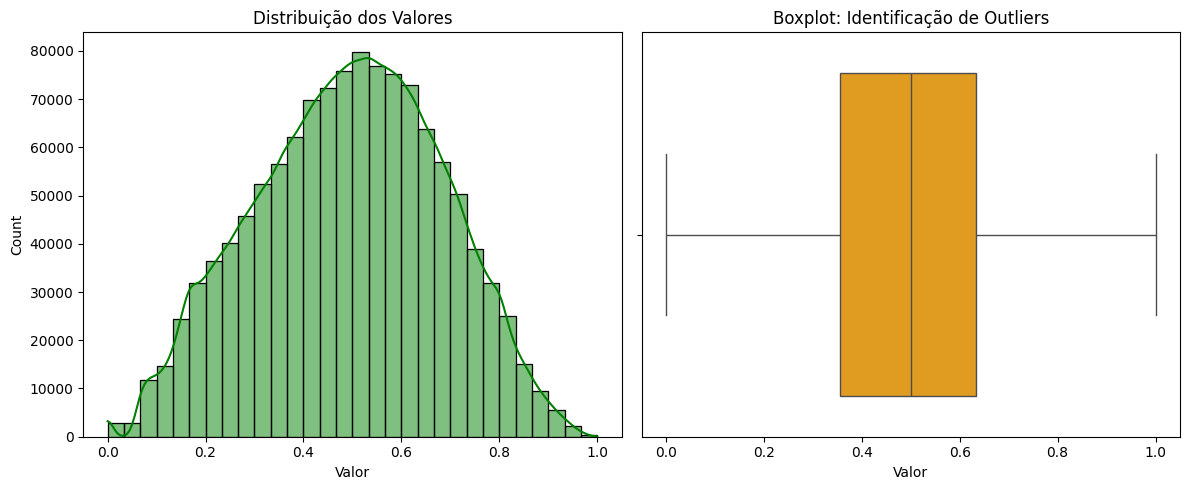

In [6]:
visual = inicial.select("danceability").collect().to_series()

plt.figure(figsize=(12, 5))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(visual, bins=30, kde=True, color='green')
plt.title('Distribuição dos Valores')
plt.xlabel('Valor')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=visual, color='orange')
plt.title('Boxplot: Identificação de Outliers')
plt.xlabel('Valor')

plt.tight_layout()
plt.show()

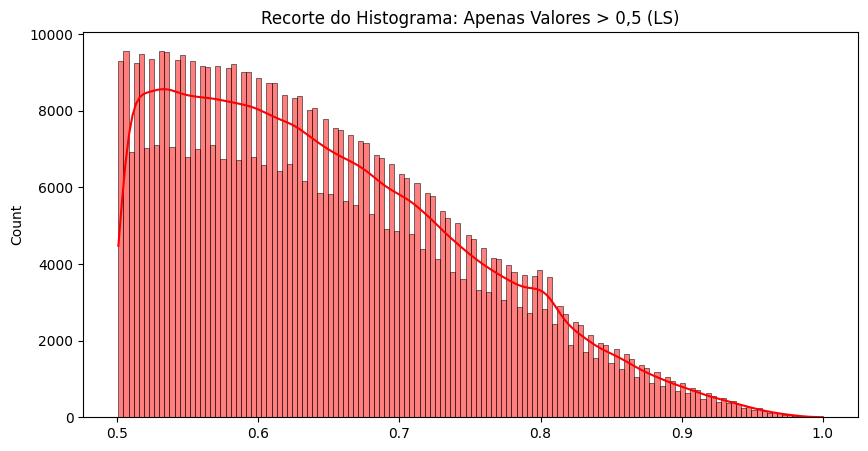

In [10]:
visual_superiores = inicial.filter(pl.col("danceability") > 0.5).select("danceability").collect().to_series()

plt.figure(figsize=(10, 5))
sns.histplot(visual_superiores, kde=True, color='red')
plt.title('Recorte do Histograma: Apenas Valores > 0,5 (LS)')
plt.show()